# Architecture

Input sentence → Encoder → Context → Decoder → Output sentence


In [1]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. DATA (you can modify)
input_sentences = [
    "i am happy",
    "i am sad",
    "he is good",
    "she is good",
    "i like tea",
    "i like food"
]

target_sentences = [
    "start मैं खुश हूँ end",
    "start मैं उदास हूँ end",
    "start वह अच्छा है end",
    "start वह अच्छी है end",
    "start मुझे चाय पसंद है end",
    "start मुझे खाना पसंद है end"
]

# 2. Tokenization
input_tokenizer = Tokenizer()
target_tokenizer = Tokenizer()

input_tokenizer.fit_on_texts(input_sentences)
target_tokenizer.fit_on_texts(target_sentences)

input_seq = input_tokenizer.texts_to_sequences(input_sentences)
target_seq = target_tokenizer.texts_to_sequences(target_sentences)

# 3. Padding
max_len_input = max(len(seq) for seq in input_seq)
max_len_target = max(len(seq) for seq in target_seq)

input_seq = pad_sequences(input_seq, maxlen=max_len_input, padding='post')
target_seq = pad_sequences(target_seq, maxlen=max_len_target, padding='post')

# 4. Decoder input/output
decoder_input = target_seq[:, :-1]
decoder_output = target_seq[:, 1:]

# 5. Model parameters
vocab_size_input = len(input_tokenizer.word_index) + 1
vocab_size_target = len(target_tokenizer.word_index) + 1
latent_dim = 64

# 6. Encoder
encoder_inputs = Input(shape=(max_len_input,))
encoder_embedding = Embedding(vocab_size_input, latent_dim)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)

_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# 7. Decoder
decoder_inputs = Input(shape=(max_len_target - 1,))
decoder_embedding = Embedding(vocab_size_target, latent_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = Dense(vocab_size_target, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# 8. Final Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# 9. Train
model.fit(
    [input_seq, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=300,
    verbose=0
)

# 10. Reverse mapping
reverse_target_index = {v: k for k, v in target_tokenizer.word_index.items()}
target_word_index = target_tokenizer.word_index

# 11. Inference models
# Encoder model
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder model
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_embedding,
    initial_state=decoder_states_inputs
)

decoder_states = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states
)

# 12. Translation function
def translate(sentence):
    seq = input_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_len_input, padding='post')

    states = encoder_model.predict(seq, verbose=0)

    target_seq = np.array([[target_word_index['start']]])

    output_sentence = []

    for _ in range(max_len_target):
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states, verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_target_index.get(sampled_token_index, '')

        if sampled_word == 'end':
            break

        output_sentence.append(sampled_word)

        target_seq = np.array([[sampled_token_index]])
        states = [h, c]

    return " ".join(output_sentence)







मैं खुश हूँ
मुझे चाय पसंद है
वह अच्छा है


In [4]:
# 13. Test

print(translate("i am happy"))

print(translate("i like tea"))
print(translate("Good tea, I like. "))

print(translate("he is good"))

मैं खुश हूँ
मुझे चाय पसंद है
मुझे चाय पसंद है
वह अच्छा है


# OPTIONAL (Visualization) - FIU

Translation: मुझे पसंद है


C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from current font.
  plt.tight_layout()
C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from current font.
  plt.tight_layout()
C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Glyph 2333 (\N{DEVANAGARI LETTER JHA}) missing from current font.
  plt.tight_layout()
C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from current font.
  plt.tight_layout()
C:\Users\hi\AppData\Local\Temp\ipykernel_16264\1949174472.py:196: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from current font.
  plt.tight_layout()
C:\Users\

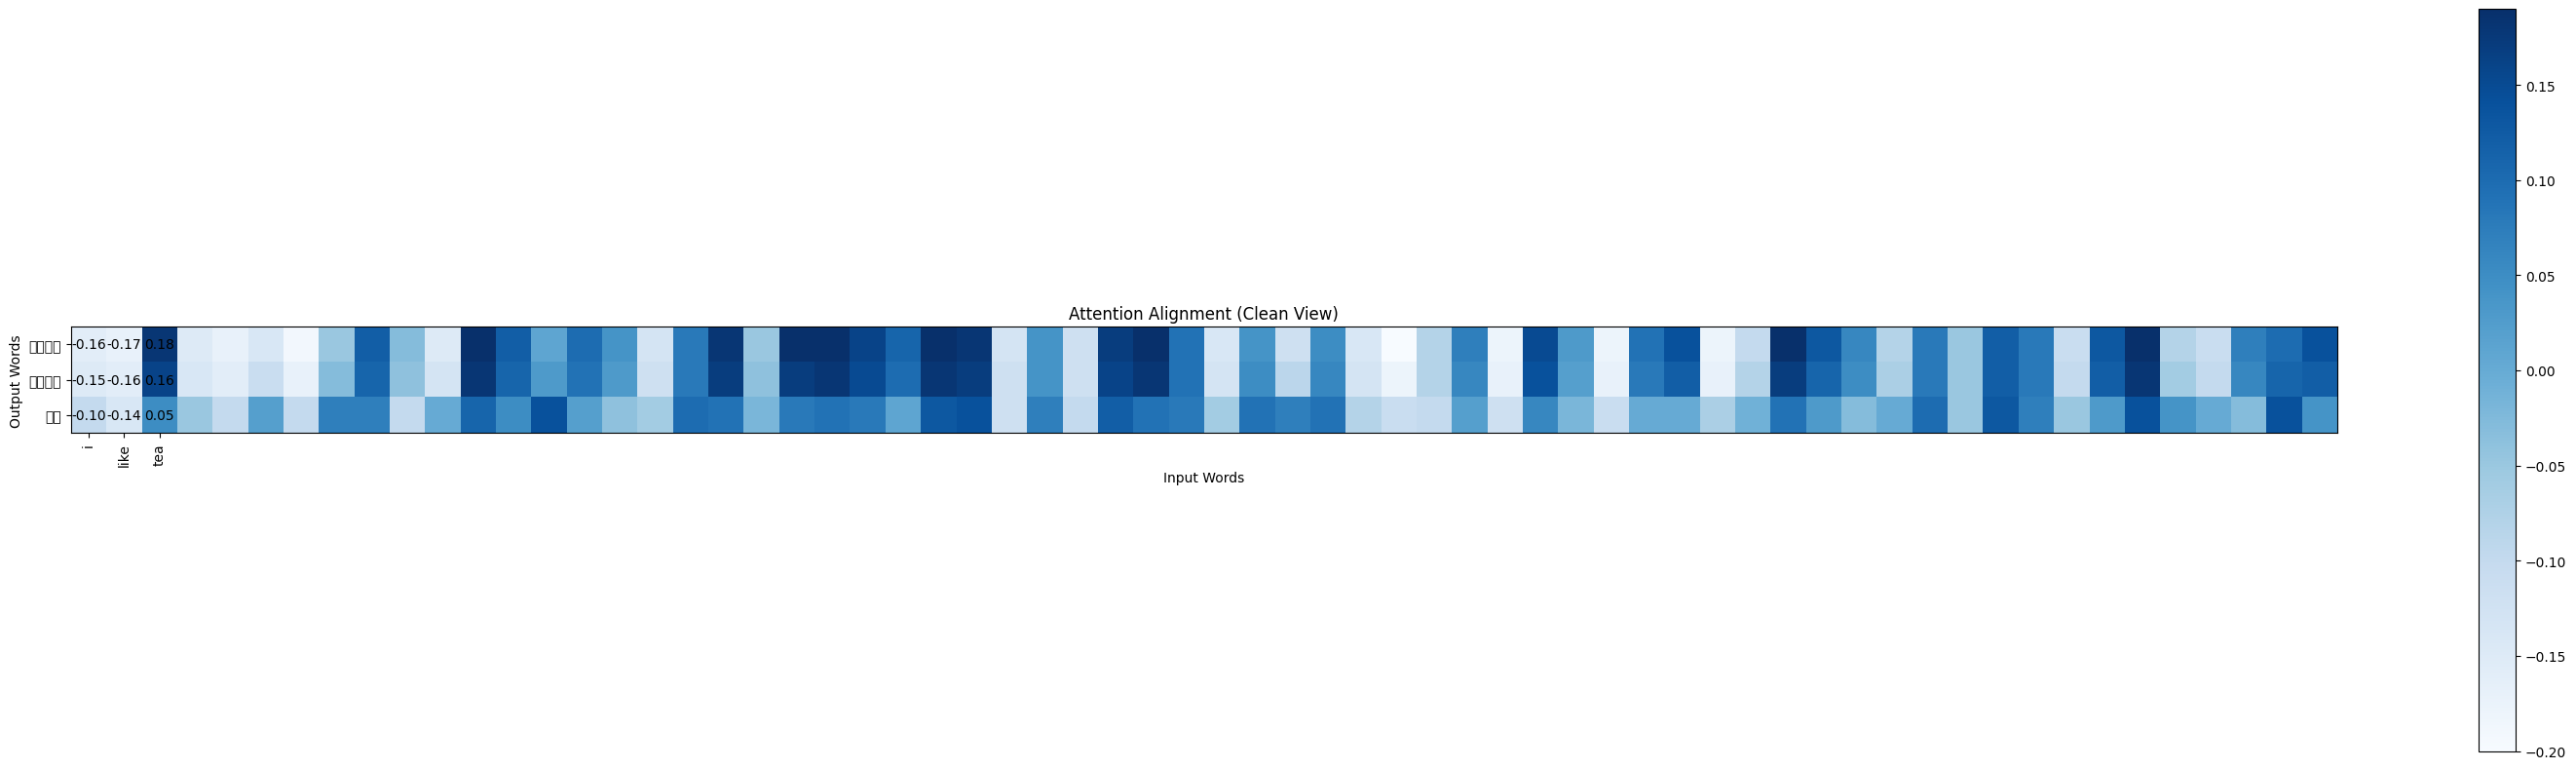

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --------------------------
# 1. DATA
# --------------------------
input_sentences = [
    "i am happy",
    "i am sad",
    "he is good",
    "she is good",
    "i like tea",
    "i like food"
]

target_sentences = [
    "start मैं खुश हूँ end",
    "start मैं उदास हूँ end",
    "start वह अच्छा है end",
    "start वह अच्छी है end",
    "start मुझे चाय पसंद है end",
    "start मुझे खाना पसंद है end"
]

# --------------------------
# 2. Tokenization
# --------------------------
input_tokenizer = Tokenizer()
target_tokenizer = Tokenizer()

input_tokenizer.fit_on_texts(input_sentences)
target_tokenizer.fit_on_texts(target_sentences)

input_seq = input_tokenizer.texts_to_sequences(input_sentences)
target_seq = target_tokenizer.texts_to_sequences(target_sentences)

max_len_input = max(len(seq) for seq in input_seq)
max_len_target = max(len(seq) for seq in target_seq)

input_seq = pad_sequences(input_seq, maxlen=max_len_input, padding='post')
target_seq = pad_sequences(target_seq, maxlen=max_len_target, padding='post')

decoder_input = target_seq[:, :-1]
decoder_output = target_seq[:, 1:]

# --------------------------
# 3. Parameters
# --------------------------
vocab_size_input = len(input_tokenizer.word_index) + 1
vocab_size_target = len(target_tokenizer.word_index) + 1
latent_dim = 64

# --------------------------
# 4. Encoder
# --------------------------
encoder_inputs = Input(shape=(max_len_input,))
enc_emb = Embedding(vocab_size_input, latent_dim)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# --------------------------
# 5. Decoder
# --------------------------
decoder_inputs = Input(shape=(max_len_target - 1,))
dec_emb = Embedding(vocab_size_target, latent_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# --------------------------
# 6. Attention
# --------------------------
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Combine
concat = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention_output])

decoder_dense = Dense(vocab_size_target, activation='softmax')
decoder_outputs = decoder_dense(concat)

# --------------------------
# 7. Model
# --------------------------
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# --------------------------
# 8. Train
# --------------------------
model.fit(
    [input_seq, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=300,
    verbose=0
)

# --------------------------
# 9. Inference setup
# --------------------------
reverse_target_index = {v: k for k, v in target_tokenizer.word_index.items()}
target_word_index = target_tokenizer.word_index

encoder_model = Model(encoder_inputs, encoder_outputs)

# Decoder states
dec_state_input_h = Input(shape=(latent_dim,))
dec_state_input_c = Input(shape=(latent_dim,))
enc_out_input = Input(shape=(max_len_input, latent_dim))

dec_outputs, h, c = decoder_lstm(
    dec_emb, initial_state=[dec_state_input_h, dec_state_input_c]
)

attn_out = attention_layer([dec_outputs, enc_out_input])
concat2 = tf.keras.layers.Concatenate(axis=-1)([dec_outputs, attn_out])
dec_outputs = decoder_dense(concat2)

decoder_model = Model(
    [decoder_inputs, enc_out_input, dec_state_input_h, dec_state_input_c],
    [dec_outputs, h, c, attn_out]
)

# --------------------------
# 10. Translate + collect attention
# --------------------------
def translate_with_attention(sentence):
    seq = input_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_len_input, padding='post')

    enc_out = encoder_model.predict(seq, verbose=0)

    target_seq = np.array([[target_word_index['start']]])
    states = [np.zeros((1, latent_dim)), np.zeros((1, latent_dim))]

    output_words = []
    attention_weights = []

    for _ in range(max_len_target):
        output, h, c, attn = decoder_model.predict(
            [target_seq, enc_out] + states, verbose=0
        )

        idx = np.argmax(output[0, -1, :])
        word = reverse_target_index.get(idx, '')

        if word == 'end':
            break

        output_words.append(word)
        attention_weights.append(attn[0, -1, :])

        target_seq = np.array([[idx]])
        states = [h, c]

    return output_words, attention_weights, seq

# --------------------------
# 11. Visualization
# --------------------------
def plot_attention(input_sentence, output_words, attention_weights):
    input_words = input_sentence.split()

    attention_matrix = np.array(attention_weights)

    # Normalize (VERY IMPORTANT for clarity)
    attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)
    attention_matrix = np.round(attention_matrix, 2)


    plt.figure(figsize=(30, 8))

    plt.imshow(attention_matrix, cmap='Blues')

    # Proper ticks
    plt.xticks(range(len(input_words)), input_words, rotation=90)
    plt.yticks(range(len(output_words)), output_words)

    # Add values inside cells (very helpful)
    for i in range(len(output_words)):
        for j in range(len(input_words)):
            value = attention_matrix[i, j]
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

    plt.xlabel("Input Words")
    plt.ylabel("Output Words")
    plt.title("Attention Alignment (Clean View)")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

# --------------------------
# 12. Test
# --------------------------
sentence = "i like tea"

output_words, attn, seq = translate_with_attention(sentence)

print("Translation:", " ".join(output_words))
plot_attention(sentence, output_words, attn)
